# Cutoff and K-Points Convergence
Run each cell once the jobs from the previous cell are complete.

In [13]:
# import relevant packages
import numpy as np
import matplotlib.pyplot as plt
import ase
from ase.io import read
from ase import Atoms
import csv

In [14]:
CONFIG = {
    # Notebook parameters
    'energy_convergence': False,
    'kpoints_convergence': False,

    # Base input file
    'reference_input_file': "4-03a"
}
# Convergence parameters
energy_cutoffs = np.arange(20, 105, 5) # 105-160
rho_ratios = [4, 8, 12]
kpts = np.arange(1, 16)
offsets = [0, 1]
threshold = 0.001 # eV


In [15]:
with open(f'{CONFIG["reference_input_file"]}.relax.in', 'r') as f:
    ref_input = f.readlines()

ions_index = None
atomic_species_index = None
# remove &IONS until ATOMIC_SPECIES sections
for i, line in enumerate(ref_input):
    if '&IONS' in line:
        ions_index = i
    if 'ATOMIC_SPECIES' in line:
        atomic_species_index = i
    if 'calculation' in line:
        ref_input[i] = f'   calculation = scf\n'
ref_input = ref_input[:ions_index] + ref_input[atomic_species_index:]

In [16]:
for ratio in rho_ratios:
    for cutoff in energy_cutoffs:
        # Replace the energy cutoff line with the new energy cutoff
        for i, line in enumerate(ref_input):
            if 'outdir' in line:
                ref_input[i] = f'   outdir = "./{CONFIG["reference_input_file"]}_{ratio}_{cutoff}"\n'
            if 'prefix' in line:
                ref_input[i] = f'   prefix = "{CONFIG["reference_input_file"]}_{ratio}_{cutoff}"\n'
            if 'ecutwfc' in line:
                ref_input[i] = f'   ecutwfc = {cutoff}\n'
            if 'ecutrho' in line:
                ref_input[i] = f'   ecutrho = {cutoff * ratio}\n'

        # Write the new input file
        with open(f'{CONFIG["reference_input_file"]}_{ratio}_{cutoff}.scf.in', 'w') as f:
            f.writelines(ref_input)         

In [17]:
# Create template and define sbatch command

_sbatch_template = """\
#!/bin/bash
#SBATCH -p cpuonly
#SBATCH -N 1
#SBATCH --ntasks-per-node=32
#SBATCH --job-name={name}
#SBATCH -t 3:00:00  # set a limit on the total run time
#SBATCH -o {name}.out
#SBATCH -e {name}.err

ulimit -s unlimited
ulimit -a  # Print all limits for debugging
export OMP_NUM_THREADS=1

SECONDS=0
module purge
module load psc.allocations.user/1.0
module load intel-oneapi-compilers/2022.1.0 intel-oneapi-mkl/2022.1.0 intel-oneapi-mpi/2021.6.0

PW=/trace/group/dabo/shared/software/qe/qe-7.4.1/build/bin/pw.x
BASENAME="{name}"

mkdir -p $BASENAME
mpirun -np "${{SLURM_NTASKS}}" $PW -in $BASENAME.scf.in > $BASENAME/$BASENAME.scf.out 2>&1

duration=$SECONDS
time=`date +%Y%m%d-%H%M%S`
echo "scf is completed in $((duration / 60)) minutes and $((duration % 60)) seconds, date:${{time}}." >> $BASENAME/$BASENAME.scf.out
"""

def create_sbatch_script(name):
    with open(f"run_convergence.sh", "w") as f:
        f.write(_sbatch_template.format(name=name))


In [18]:
# run sbatch
if CONFIG['energy_convergence']:
    for ratio in rho_ratios:
        for cutoff in energy_cutoffs:
            name = f"{CONFIG['reference_input_file']}_{ratio}_{cutoff}"
            create_sbatch_script(name)
            !sbatch run_convergence.sh

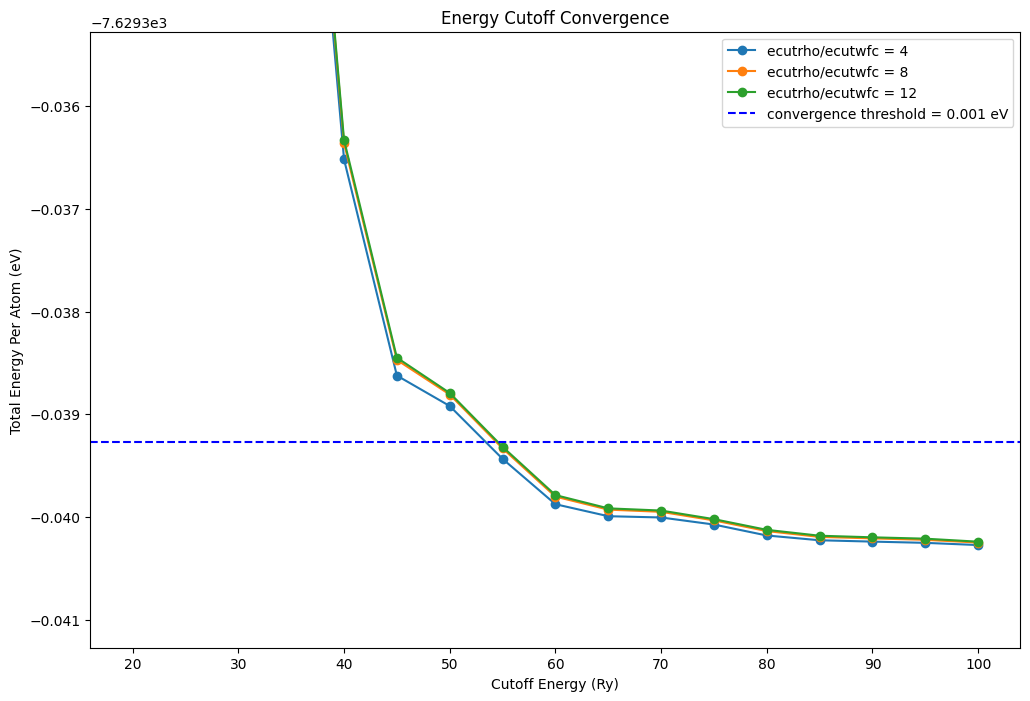

In [19]:
# plot
all_energies_ecut = [[] for _ in rho_ratios]
for iratio, ratio in enumerate(rho_ratios):
    for cutoff in energy_cutoffs:
        output = read(
            f"{CONFIG['reference_input_file']}_{ratio}_{cutoff}/"
            f"{CONFIG['reference_input_file']}_{ratio}_{cutoff}.scf.out",
            format="espresso-out",
        )
        all_energies_ecut[iratio].append(output.get_total_energy())

# make division/plotting work reliably
all_energies_ecut = [np.asarray(e, dtype=float) for e in all_energies_ecut]

natoms = 16

plt.figure(figsize=(12, 8))
for iratio, ratio in enumerate(rho_ratios):
    plt.plot(
        energy_cutoffs,
        all_energies_ecut[iratio] / natoms,
        label=f"ecutrho/ecutwfc = {ratio}",
        marker="o",
    )
plt.xlabel("Cutoff Energy (Ry)")
plt.ylabel("Total Energy Per Atom (eV)")
plt.ylim(
    np.min(all_energies_ecut[0]) / natoms - 0.001,
    np.min(all_energies_ecut[0]) / natoms + 0.005,
)
plt.axhline(
    y=np.min(all_energies_ecut[0]) / natoms + threshold,
    color="blue",
    linestyle="--",
    label=f"convergence threshold = {threshold} eV",
)
plt.title("Energy Cutoff Convergence")
plt.legend()
plt.show()

In [20]:
# Save data to csv file

# Create a list to store the data
data = []

# Add the data to the list
for iratio, ratio in enumerate(rho_ratios):
    for icutoff, cutoff in enumerate(energy_cutoffs):
        data.append([ratio, cutoff, all_energies_ecut[iratio][icutoff-1], all_energies_ecut[iratio][icutoff-1] / natoms])

# Write the data to a CSV file
with open('energy_convergence.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['ecutrho/ecutwfc', 'cutoff (Ry)', 'energy (eV)', 'energy/atom (eV)'])
    writer.writerows(data)


# Repeat for K-points Convergence

In [21]:
# Remove k-points and add converged energies
ecutwfc = 55
ecutrho = ecutwfc * 4
kpts_index = None
cell_index = None
for i, line in enumerate(ref_input):
    if 'ecutwfc' in line:
        ref_input[i] = f'   ecutwfc = {ecutwfc}\n'
    if 'ecutrho' in line:
        ref_input[i] = f'   ecutrho = {ecutrho}\n'
    if 'K_POINTS' in line:
        kpts_index = i
    if 'CELL_PARAMETERS' in line:
        cell_index = i
ref_input = ref_input[:kpts_index+1] + ref_input[cell_index-1:]

for offset in offsets:
    for kpt in kpts:
        # Replace the energy cutoff line with the new energy cutoff
        for i, line in enumerate(ref_input):
            if 'outdir' in line:
                ref_input[i] = f'   outdir = "./{CONFIG["reference_input_file"]}_{offset}_{kpt}"\n'
            if 'prefix' in line:
                ref_input[i] = f'   prefix = "{CONFIG["reference_input_file"]}_{offset}_{kpt}"\n'
            if 'K_POINTS' in line:
                ref_input[i] = f'K_POINTS automatic\n {kpt} {kpt} 1   {offset} {offset} {offset}\n'

        # write the new input file
        with open(f'{CONFIG["reference_input_file"]}_{offset}_{kpt}.scf.in', 'w') as f:
            f.writelines(ref_input)
            

In [22]:
if CONFIG['kpoints_convergence']:
    for offset in offsets:
        for kpt in kpts:
            name = f"{CONFIG['reference_input_file']}_{offset}_{kpt}"
            create_sbatch_script(name)
            !sbatch run_convergence.sh

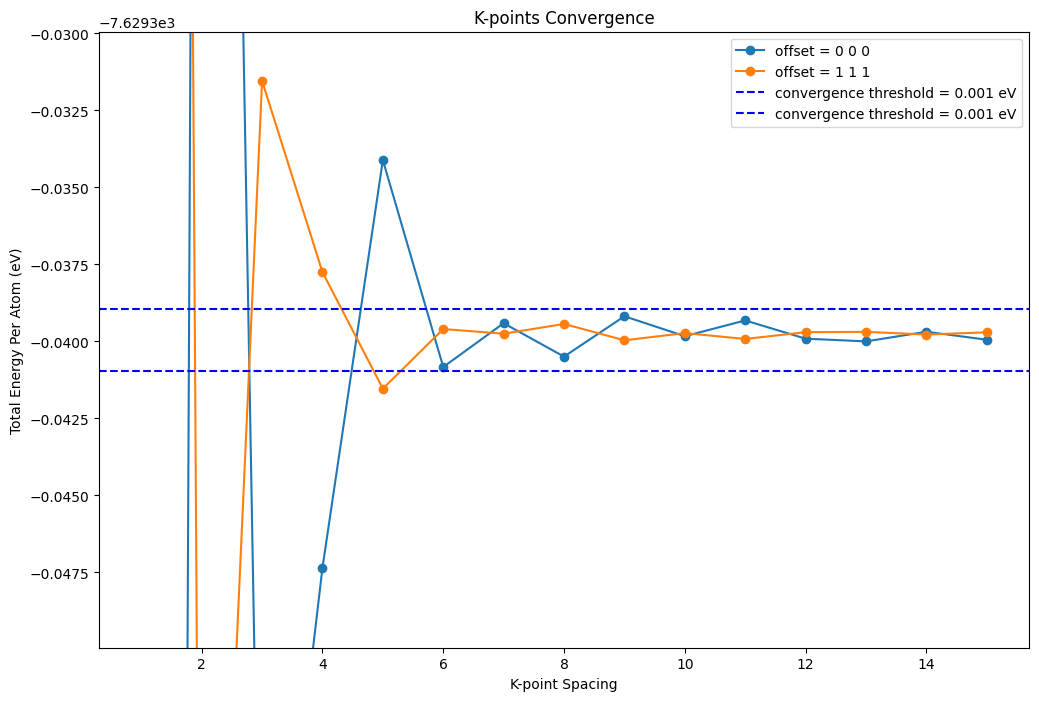

In [23]:
# plot
all_energies_kpts = [[] for _ in offsets]
energies_per_atom_kpts = [[] for _ in offsets]
for ioffset, offset in enumerate(offsets):
    for ikpt, kpt in enumerate(kpts):
        output = read(
            f"{CONFIG['reference_input_file']}_{offset}_{kpt}/"
            f"{CONFIG['reference_input_file']}_{offset}_{kpt}.scf.out",
            format="espresso-out",
        )
        all_energies_kpts[ioffset].append(output.get_total_energy())
        energies_per_atom_kpts[ioffset].append(output.get_total_energy() / natoms)

plt.figure(figsize=(12,8))
for ioffset, offset in enumerate(offsets):
    plt.plot(kpts, energies_per_atom_kpts[ioffset], label=f'offset = {offset} {offset} {offset}', marker='o')
plt.xlabel('K-point Spacing')
plt.ylabel('Total Energy Per Atom (eV)')
plt.ylim(energies_per_atom_kpts[0][-1]-0.01, energies_per_atom_kpts[0][-1]+0.01)
plt.axhline(
    y=np.min(energies_per_atom_kpts[0][-1]) + threshold,
    color="blue",
    linestyle="--",
    label=f"convergence threshold = {threshold} eV",
)
plt.axhline(
    y=np.min(energies_per_atom_kpts[0][-1]) - threshold,
    color="blue",
    linestyle="--",
    label=f"convergence threshold = {threshold} eV",
)
plt.title('K-points Convergence')
plt.legend()
plt.show()

In [24]:
# Create a list to store the data
kpts_data = []

# Add the data to the list
for ioffset, offset in enumerate(offsets):
    for ikpt, kpt in enumerate(kpts):
        kpts_data.append([offset, kpt, all_energies_kpts[ioffset][ikpt-1], all_energies_kpts[ioffset][ikpt-1] / natoms])

# Write the data to a CSV file
with open('kpts_convergence.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['offset', 'kpt', 'energy (eV)', 'energy/atom (eV)'])
    writer.writerows(kpts_data)